<div style="background:linear-gradient(135deg,#1a3a5c,#2980b9);border-radius:12px;padding:30px;text-align:center;margin-bottom:20px;">
  <h1 style="color:white;margin:0;font-size:32px;letter-spacing:1px;">Omar Gamal ElKady</h1>
  <p style="color:#cce4ff;margin:8px 0 4px;font-size:16px;">ITI Intake 46 &mdash; Track AI</p>
  <hr style="border:1px solid rgba(255,255,255,0.3);width:50%;margin:14px auto;">
  <h2 style="color:white;margin:0;font-size:24px;font-weight:400;">Lab 4: Supervised Machine Learning for Time Series &mdash; BTC-USD Forecasting</h2>
</div>

<div style="background:#f8faff;border:1px solid #d0e4f7;border-radius:10px;padding:20px;margin-bottom:15px;">
  <h3 style="color:#2e6da4;margin:0 0 12px;text-align:center;">Lab Roadmap</h3>
  <table border="0" cellpadding="10" cellspacing="0" style="border-collapse:collapse;width:100%;font-size:14px;color:#000;">
    <thead>
      <tr style="background:#2e6da4;color:white;">
        <th style="border-radius:6px 0 0 0;padding:10px;">#</th>
        <th>Section</th><th>Focus</th><th style="border-radius:0 6px 0 0;">Goal</th>
      </tr>
    </thead>
    <tbody>
      <tr style="background:#eaf4ff;"><td style="text-align:center;font-weight:bold;">1</td><td>Data Preparation</td><td style="text-align:center;">Tasks 1&ndash;3</td><td>Load BTC 1-minute data, resample to daily, and engineer time embeddings, lag and rolling features.</td></tr>
      <tr style="background:#f8faff;"><td style="text-align:center;font-weight:bold;">2</td><td>Model Training</td><td style="text-align:center;">Tasks 4&ndash;5</td><td>Perform a chronological 80/20 split and train an XGBoost model on the tabular time series.</td></tr>
      <tr style="background:#eaf4ff;"><td style="text-align:center;font-weight:bold;">3</td><td>Evaluation</td><td style="text-align:center;">Task 6</td><td>Compute RMSE, visualize predictions, and observe the extrapolation problem in tree-based models.</td></tr>
      <tr style="background:#f8faff;"><td style="text-align:center;font-weight:bold;">4</td><td>Multi-Step Forecasting</td><td style="text-align:center;">Task 7</td><td>Implement the Direct Strategy for 3-day ahead forecasting to avoid compounding errors.</td></tr>
      <tr style="background:#eaf4ff;"><td style="text-align:center;font-weight:bold;">5</td><td>Fixing Extrapolation</td><td style="text-align:center;">FA 1</td><td>Use ElasticNet to capture the trend and XGBoost on residuals to overcome the extrapolation ceiling.</td></tr>
      <tr style="background:#f8faff;"><td style="text-align:center;font-weight:bold;">6</td><td>Sinusoidal Encoding</td><td style="text-align:center;">FA 2</td><td>Replace raw cyclical features with sin/cos encoding and measure the impact on forecast accuracy.</td></tr>
    </tbody>
  </table>
</div>

In [292]:
# Run this cell to install necessary libraries if you haven't already
# !pip install kagglehub xgboost scikit-learn pandas matplotlib

In [293]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import warnings
warnings.filterwarnings("ignore")

# Download the BTC dataset
# path = kagglehub.dataset_download("imranbukhari/comprehensive-btcusd-1m-data", output_dir="btc_data")
# print("Path to dataset ready at:", path)
# data_path = path + "/btc_1m.csv" # Note: you may need to adjust the exact filename based on the extracted contents
data_path = 'btc_data/BTCUSD_1m_Binance.csv'

<div style="background:linear-gradient(135deg,#1a3a5c,#2e6da4);border-radius:10px;padding:18px 24px;margin:20px 0 10px;">
  <h2 style="color:white;margin:0;font-size:20px;">&#9679; Task 1: Load and Resample the Data</h2>
  <p style="margin:5px 0 0;font-size:14px;color:#cce4ff;font-weight:400;">BTC-USD 1-Minute &rarr; Daily</p>
</div>
<div style="background:#f8faff;border:1px solid #d0e4f7;border-radius:8px;padding:14px 18px;margin:8px 0;">
  <p style="margin:0;color:#2c3e50;line-height:1.7;">Load the Binance 1-minute CSV, convert the timestamp to a datetime index, and resample to daily frequency using <code>.last()</code> for Close and <code>.sum()</code> for Volume.</p>
</div>

In [294]:
# Load the CSV
df = pd.read_csv(data_path)

# Convert 'Open time' to datetime and set as index
df['Open time'] = pd.to_datetime(df['Open time'])
df = df.set_index('Open time')

# Resample to daily frequency
df_daily = pd.DataFrame()
df_daily['Close'] = df['Close'].resample('D').last()
df_daily['Volume'] = df['Volume'].resample('D').sum()

print(df_daily.shape)
df_daily.head()

(2978, 2)


,Close,Volume
Open time,,
2017-08-17,4285.08,795.150377
2017-08-18,4108.37,1199.888264
2017-08-19,4139.98,381.309763
2017-08-20,4086.29,467.083022
2017-08-21,4016.00,691.743060


<!-- <div style="background:#f0fff4;border-left:5px solid #27ae60;border-radius:0 8px 8px 0;padding:15px 20px;margin:10px 0;">
  <h3 style="color:#1e8449;margin:0 0 10px;">&#10004; Task 1 &mdash; Observations</h3>
  <ul style="margin:0;padding-left:20px;color:#2c3e50;line-height:1.7;">
    <li>The dataset was successfully resampled from ~4.3 million 1-minute rows to ~2,500 daily rows.</li>
    <li>Each row now represents one full trading day: closing price and total volume traded.</li>
  </ul>
</div> -->

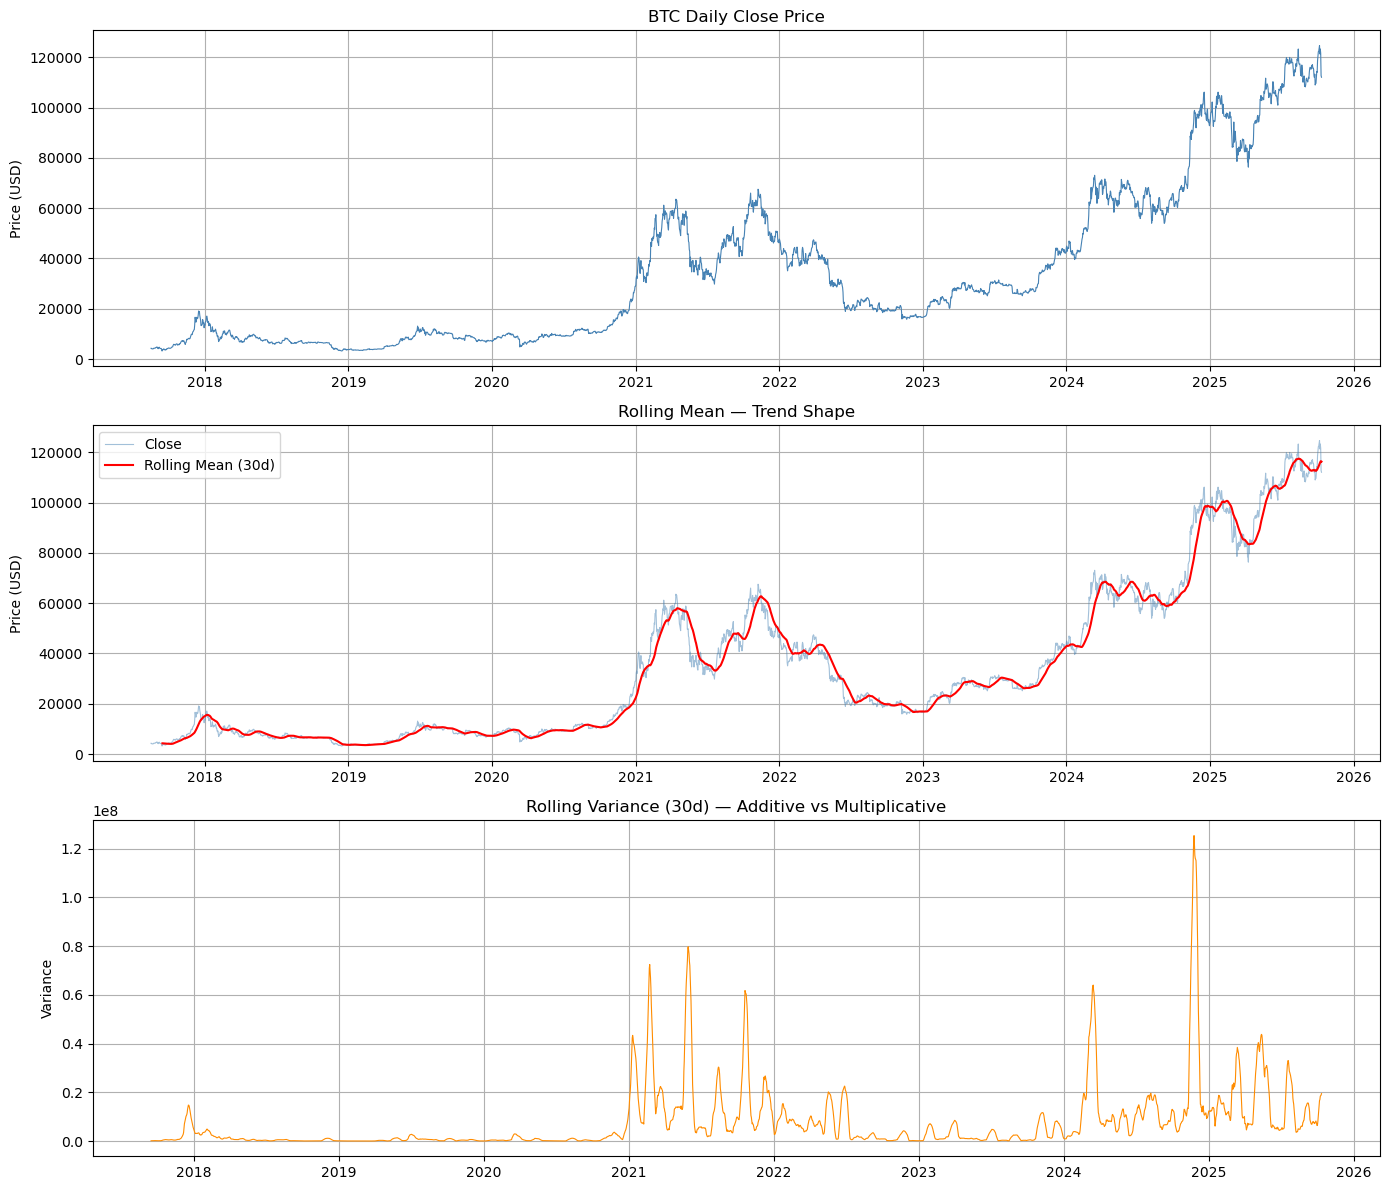

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# 1. Raw Daily Close Price
axes[0].plot(df_daily["Close"], color="steelblue", linewidth=0.8)
axes[0].set_title("BTC Daily Close Price")
axes[0].set_ylabel("Price (USD)")
axes[0].grid()

# 2. Rolling Mean (trend) — window of 30 days
rolling_mean = df_daily["Close"].rolling(30).mean()
axes[1].plot(df_daily["Close"], color="steelblue", linewidth=0.8, alpha=0.5, label="Close")
axes[1].plot(rolling_mean, color="red", linewidth=1.5, label="Rolling Mean (30d)")
axes[1].set_title("Rolling Mean — Trend Shape")
axes[1].set_ylabel("Price (USD)")
axes[1].legend()
axes[1].grid()

# 3. Rolling Variance — to identify additive vs multiplicative error
rolling_var = df_daily["Close"].rolling(30).var()
axes[2].plot(rolling_var, color="darkorange", linewidth=0.8)
axes[2].set_title("Rolling Variance (30d) — Additive vs Multiplicative")
axes[2].set_ylabel("Variance")
axes[2].grid()

plt.tight_layout()
plt.show()

<div style="background:#f0fff4;border-left:5px solid #27ae60;border-radius:0 8px 8px 0;padding:15px 20px;margin:10px 0;">
  <h3 style="color:#1e8449;margin:0 0 10px;">&#10004; Exploratory Visualization &mdash; Observations</h3>
  <ul style="margin:0;padding-left:20px;color:#2c3e50;line-height:1.7;">
    <li>The rolling mean reveals a clear <strong>exponential upward trend</strong> &mdash; BTC grew from ~$5K to highs above $60K.</li>
    <li>The rolling variance <strong>grows with the price level</strong>, confirming <strong>multiplicative error</strong>: price swings are proportional to price level, not constant.</li>
  </ul>
</div>

<div style="background:linear-gradient(135deg,#1a3a5c,#2e6da4);border-radius:10px;padding:18px 24px;margin:20px 0 10px;">
  <h2 style="color:white;margin:0;font-size:20px;">&#9679; Task 2: Advanced Feature Engineering</h2>
  <p style="margin:5px 0 0;font-size:14px;color:#cce4ff;font-weight:400;">Time Embeddings</p>
</div>
<div style="background:#f8faff;border:1px solid #d0e4f7;border-radius:8px;padding:14px 18px;margin:8px 0;">
  <p style="margin:0;color:#2c3e50;line-height:1.7;">Extract temporal features so the model can learn calendar patterns: <code>day_of_week</code>, <code>month</code>, <code>day_of_year</code>, and a binary <code>is_weekend</code> flag.</p>
</div>

In [296]:
# YOUR CODE HERE
df_daily['day_of_week'] = df_daily.index.dayofweek
df_daily['month'] = df_daily.index.month
df_daily['day_of_year'] = df_daily.index.dayofyear
df_daily['is_weekend'] = (df_daily.index.dayofweek >= 5).astype(int)

df_daily.head()

,Close,Volume,day_of_week,month,day_of_year,is_weekend
Open time,,,,,,
2017-08-17,4285.08,795.150377,3,8,229,0
2017-08-18,4108.37,1199.888264,4,8,230,0
2017-08-19,4139.98,381.309763,5,8,231,1
2017-08-20,4086.29,467.083022,6,8,232,1
2017-08-21,4016.00,691.743060,0,8,233,0


<!-- <div style="background:#f0fff4;border-left:5px solid #27ae60;border-radius:0 8px 8px 0;padding:15px 20px;margin:10px 0;">
  <h3 style="color:#1e8449;margin:0 0 10px;">&#10004; Task 2 &mdash; Observations</h3>
  <ul style="margin:0;padding-left:20px;color:#2c3e50;line-height:1.7;">
    <li>Four temporal features added successfully.</li>
    <li><code>is_weekend</code> may carry weaker signal for BTC than for stocks since crypto trades 24/7, but it can still capture reduced institutional activity on weekends.</li>
  </ul>
</div> -->

<div style="background:linear-gradient(135deg,#1a3a5c,#2e6da4);border-radius:10px;padding:18px 24px;margin:20px 0 10px;">
  <h2 style="color:white;margin:0;font-size:20px;">&#9679; Task 3: Advanced Feature Engineering</h2>
  <p style="margin:5px 0 0;font-size:14px;color:#cce4ff;font-weight:400;">Lags and Rolling Windows</p>
</div>
<div style="background:#f8faff;border:1px solid #d0e4f7;border-radius:8px;padding:14px 18px;margin:8px 0;">
  <p style="margin:0;color:#2c3e50;line-height:1.7;">Capture autoregressive patterns with lag features (<code>lag_1</code>, <code>lag_3</code>, <code>lag_7</code>) and rolling statistics (<code>rolling_mean_7</code>, <code>rolling_std_7</code>). Drop NaN rows after shifting.</p>
</div>

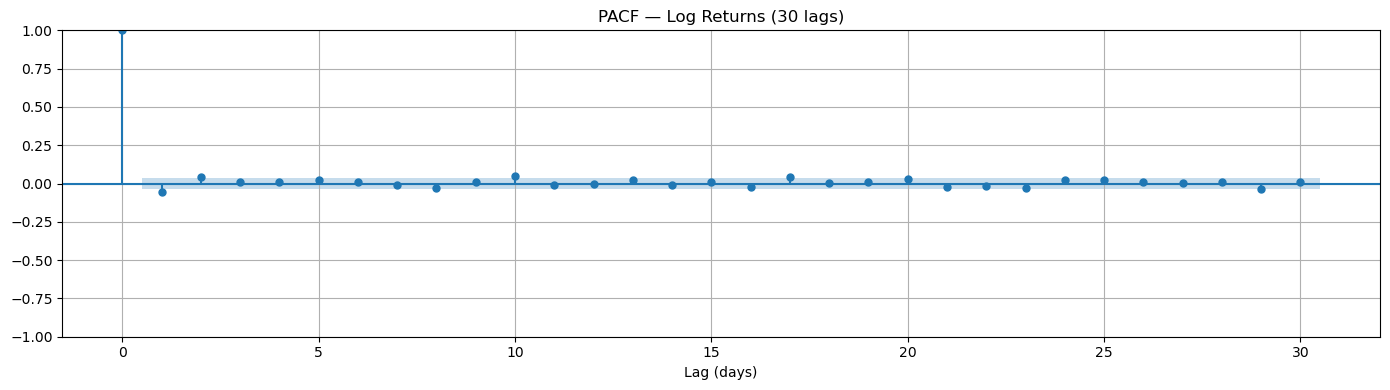

In [ ]:
# PACF — Identify which specific lags are directly useful
from statsmodels.graphics.tsaplots import plot_pacf

log_returns = np.log(df_daily["Close"]).diff().dropna()

fig, ax = plt.subplots(figsize=(14, 4))
plot_pacf(log_returns, lags=30, ax=ax)
ax.set_title("PACF — Log Returns (30 lags)")
ax.set_xlabel("Lag (days)")
ax.grid()
plt.tight_layout()
plt.show()

<div style="background:#f0fff4;border-left:5px solid #27ae60;border-radius:0 8px 8px 0;padding:15px 20px;margin:10px 0;">
  <h3 style="color:#1e8449;margin:0 0 10px;">&#10004; PACF Analysis &mdash; Observations</h3>
  <ul style="margin:0;padding-left:20px;color:#2c3e50;line-height:1.7;">
    <li>PACF on log returns shows very few significant lags beyond lag 1.</li>
  </ul>
</div>

In [298]:
# YOUR CODE HERE

# Lag features
df_daily['lag_1'] = df_daily['Close'].shift(1)
df_daily['lag_3'] = df_daily['Close'].shift(3)
df_daily['lag_7'] = df_daily['Close'].shift(7)

# Rolling window features
df_daily['rolling_mean_7'] = df_daily['Close'].rolling(7).mean()
df_daily['rolling_std_7'] = df_daily['Close'].rolling(7).std()

# Drop NaN rows generated by shifting and rolling
df_daily.dropna(inplace=True)

df_daily.head()

,Close,Volume,day_of_week,month,day_of_year,is_weekend,lag_1,lag_3,lag_7,rolling_mean_7,rolling_std_7
Open time,,,,,,,,,,,
2017-08-24,4316.01,787.418753,3,8,236,0,4114.01,4016.00,4285.08,4117.237143,97.714881
2017-08-25,4280.68,573.612740,4,8,237,0,4316.01,4040.00,4108.37,4141.852857,115.240759
2017-08-26,4337.44,228.108068,5,8,238,1,4280.68,4114.01,4139.98,4170.061429,136.847454
2017-08-27,4310.01,350.692585,6,8,239,1,4337.44,4316.01,4086.29,4202.021429,140.107823
2017-08-28,4386.69,603.841616,0,8,240,0,4310.01,4280.68,4016.00,4254.977143,127.573227


<div style="background:#f0fff4;border-left:5px solid #27ae60;border-radius:0 8px 8px 0;padding:15px 20px;margin:10px 0;">
  <h3 style="color:#1e8449;margin:0 0 10px;">&#10004; Task 3 &mdash; Observations</h3>
  <ul style="margin:0;padding-left:20px;color:#2c3e50;line-height:1.7;">
    <li>The final feature set provides the model with exact past prices (lags) and smoothed trend and variability context (rolling features).</li>
  </ul>
</div>

<div style="background:linear-gradient(135deg,#1a3a5c,#2e6da4);border-radius:10px;padding:18px 24px;margin:20px 0 10px;">
  <h2 style="color:white;margin:0;font-size:20px;">&#9679; Task 4: Chronological Train / Test Split</h2>
  <p style="margin:5px 0 0;font-size:14px;color:#cce4ff;font-weight:400;">Preventing Target Leakage</p>
</div>
<div style="background:#f8faff;border:1px solid #d0e4f7;border-radius:8px;padding:14px 18px;margin:8px 0;">
  <p style="margin:0;color:#2c3e50;line-height:1.7;">Define features and target, then split the data chronologically &mdash; first 80% for training, last 20% for testing. Never use random shuffling on time series data.</p>
</div>

In [ ]:
# YOUR CODE HERE

# Define features and target
X = df_daily.drop(columns=['Close'])
y = df_daily['Close']

# Chronological 80/20 split
split_idx = int(len(df_daily) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")
print(f"Train period: {X_train.index[0].date()} --> {X_train.index[-1].date()}")
print(f"Test period:  {X_test.index[0].date()} --> {X_test.index[-1].date()}")

Train size: 2376 | Test size: 595
Train period: 2017-08-24 → 2024-02-24
Test period:  2024-02-25 → 2025-10-11


<!-- <div style="background:#f0fff4;border-left:5px solid #27ae60;border-radius:0 8px 8px 0;padding:15px 20px;margin:10px 0;">
  <h3 style="color:#1e8449;margin:0 0 10px;">&#10004; Task 4 &mdash; Observations</h3>
  <ul style="margin:0;padding-left:20px;color:#2c3e50;line-height:1.7;">
    <li>The train period covers earlier, lower-price BTC history. The test period covers more recent, higher-price data &mdash; including potential all-time highs the model has never seen.</li>
    <li>This chronological split deliberately sets up the extrapolation problem we will observe in Task 6.</li>
  </ul>
</div> -->

<div style="background:linear-gradient(135deg,#1a3a5c,#2e6da4);border-radius:10px;padding:18px 24px;margin:20px 0 10px;">
  <h2 style="color:white;margin:0;font-size:20px;">&#9679; Task 5: Train a Tree-Based Model</h2>
  <p style="margin:5px 0 0;font-size:14px;color:#cce4ff;font-weight:400;">XGBoost Regressor</p>
</div>
<div style="background:#f8faff;border:1px solid #d0e4f7;border-radius:8px;padding:14px 18px;margin:8px 0;">
  <p style="margin:0;color:#2c3e50;line-height:1.7;">Initialize an <code>XGBRegressor</code>, fit it on the training set, and generate predictions on the test set. Inspect feature importance to understand which signals drove the model.</p>
</div>

In [300]:
# YOUR CODE HERE

# Initialize XGBRegressor
model = xgb.XGBRegressor(n_estimators=500, learning_rate=0.05, random_state=42)

# Fit on training data
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)

<div style="background:#f0fff4;border-left:5px solid #27ae60;border-radius:0 8px 8px 0;padding:15px 20px;margin:10px 0;">
  <h3 style="color:#1e8449;margin:0 0 10px;">&#10004; Task 5 &mdash; Observations</h3>
  <ul style="margin:0;padding-left:20px;color:#2c3e50;line-height:1.7;">
    <li>XGBoost trained with 500 trees and a learning rate of 0.05 &mdash; a conservative rate that works well with a large number of estimators.</li>
    <li>The model treats each day as an independent tabular row with historical features as inputs.</li>
  </ul>
</div>

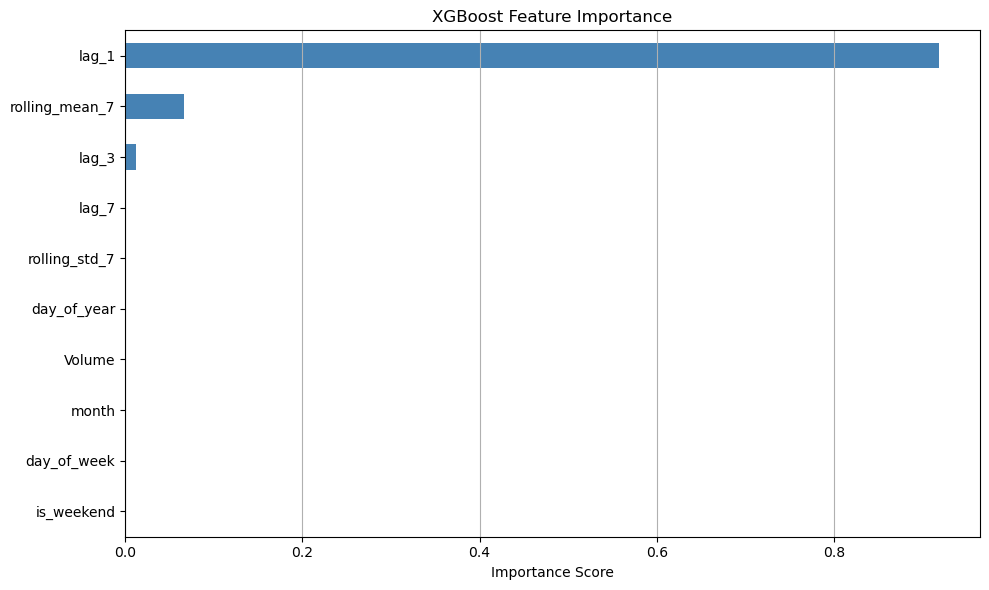

lag_1             0.919031
rolling_mean_7    0.066682
lag_3             0.012134
lag_7             0.000515
rolling_std_7     0.000408
day_of_year       0.000400
Volume            0.000399
month             0.000242
day_of_week       0.000190
is_weekend        0.000000
dtype: float32


In [301]:
# Feature Importance — which features contributed most to the model
importances = pd.Series(model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
importances.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("XGBoost Feature Importance")
ax.set_xlabel("Importance Score")
ax.grid(axis="x")
plt.tight_layout()
plt.show()

print(importances.sort_values(ascending=False))

<div style="background:#f0fff4;border-left:5px solid #27ae60;border-radius:0 8px 8px 0;padding:15px 20px;margin:10px 0;">
  <h3 style="color:#1e8449;margin:0 0 10px;">&#10004; Feature Importance &mdash; Observations</h3>
  <ul style="margin:0;padding-left:20px;color:#2c3e50;line-height:1.7;">
    <li><code>lag_1</code> is typically the dominant feature &mdash; yesterday's price is the strongest predictor of today's price.</li>
    <li><code>rolling_mean_7</code> feature capture medium-term momentum, On the other hand staring from <code>lag_7</code> to the end this features can be neglected, because they do not provide meanifull information to the model.</li>
  </ul>
</div>

<div style="background:linear-gradient(135deg,#1a3a5c,#2e6da4);border-radius:10px;padding:18px 24px;margin:20px 0 10px;">
  <h2 style="color:white;margin:0;font-size:20px;">&#9679; Task 6: Evaluation &amp; The Extrapolation Problem</h2>
</div>
<div style="background:#f8faff;border:1px solid #d0e4f7;border-radius:8px;padding:14px 18px;margin:8px 0;">
  <p style="margin:0;color:#2c3e50;line-height:1.7;">Compute RMSE on the test set, plot actual vs predicted, and observe how the model fails to follow price levels that exceed the training maximum &mdash; the fundamental extrapolation problem of tree-based models.</p>
</div>

RMSE: 31370.06


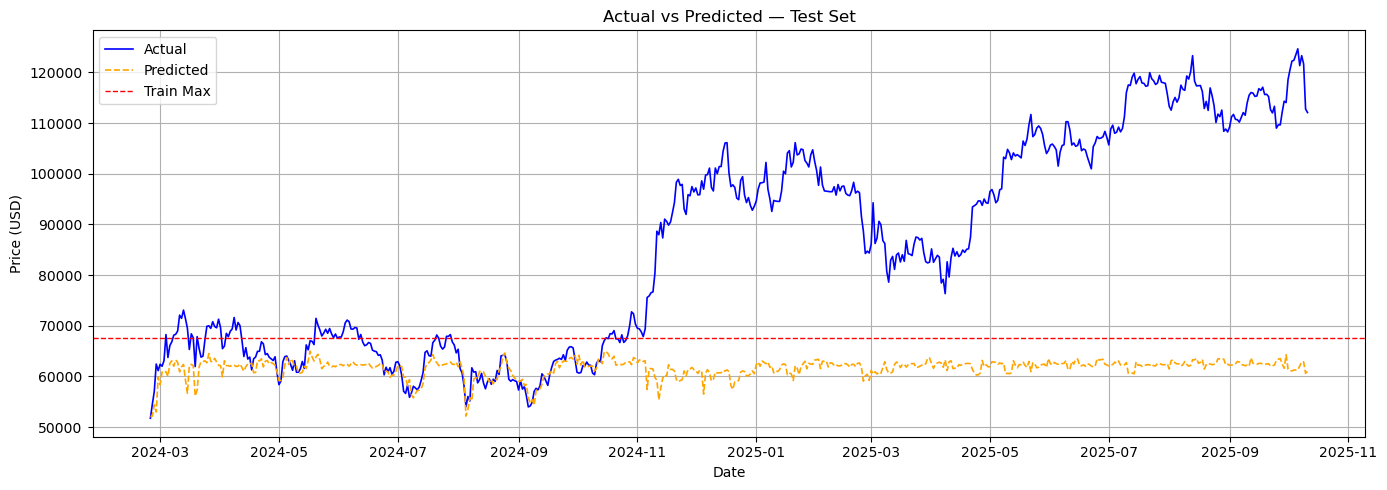

In [ ]:
# YOUR CODE HERE

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE: {rmse:.2f}")

# Full plot
train_max = y_train.max()
train_min = y_train.min()

# Actual vs Predicted — Test Set
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(y_test.index, y_test, label="Actual", color="blue", linewidth=1.2)
ax.plot(y_test.index, y_pred, label="Predicted", color="orange", linestyle="--", linewidth=1.2)
ax.axhline(train_max, color="red", linestyle="--", linewidth=1, label=f"Train Max")
ax.set_title("Actual vs Predicted — Test Set")
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

<div style="background:#f0fff4;border-left:5px solid #27ae60;border-radius:0 8px 8px 0;padding:15px 20px;margin:10px 0;">
  <h3 style="color:#1e8449;margin:0 0 10px;">&#10004; Task 6 &mdash; RMSE &mdash; Observations</h3>
  <ul style="margin:0;padding-left:20px;color:#2c3e50;line-height:1.7;">
    <li>A high RMSE on the test set is expected when BTC reaches new price levels the model has never seen.</li>
    <li>The actual vs predicted plot on the test set reveals how closely the model tracks the real price.</li>
  </ul>
</div>

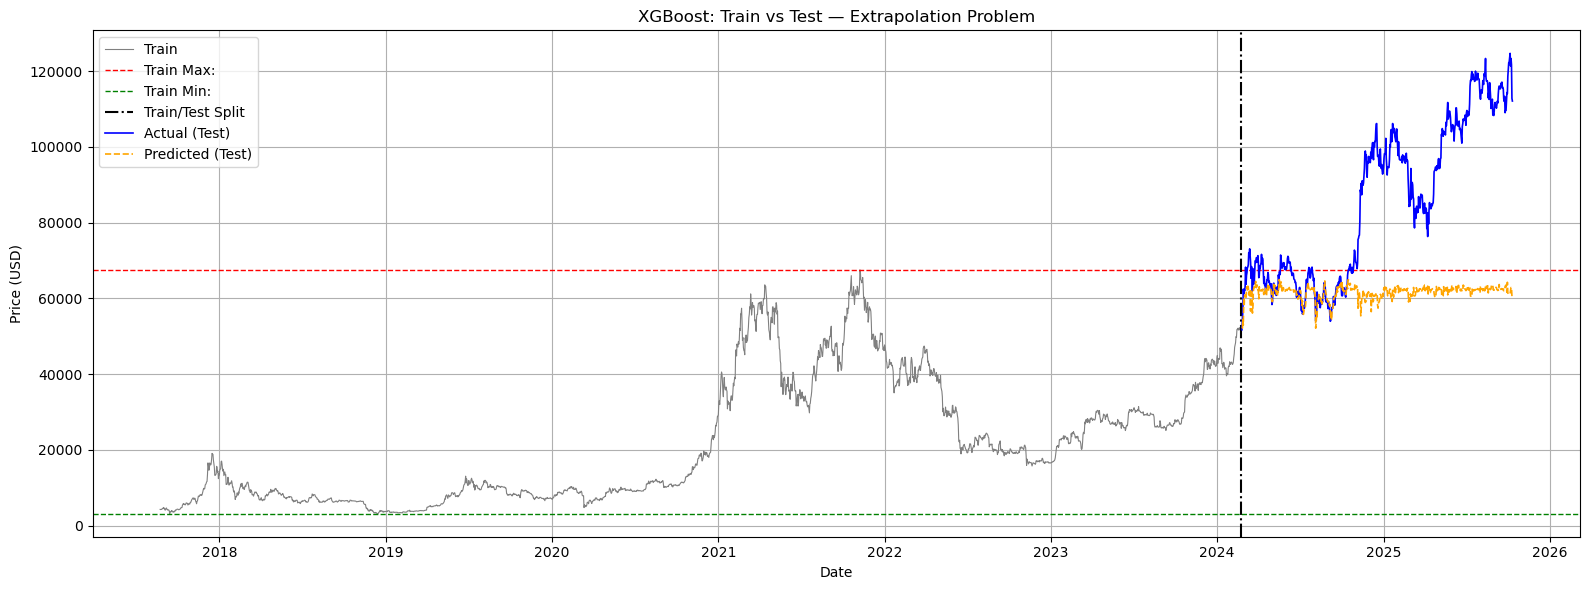

In [ ]:
fig, ax = plt.subplots(figsize=(16, 6))

# Training data
ax.plot(y_train.index, y_train, label="Train", color="gray", linewidth=0.8)

# Training range boundaries
ax.axhline(train_max, color="red", linestyle="--", linewidth=1, label=f"Train Max: ")
ax.axhline(train_min, color="green", linestyle="--", linewidth=1, label=f"Train Min: ")

# Vertical line marking train/test split
ax.axvline(x=X_train.index[-1], color="black", linestyle="-.", linewidth=1.5, label="Train/Test Split")

# Test actual vs predicted
ax.plot(y_test.index, y_test, label="Actual (Test)", color="blue", linewidth=1.2)
ax.plot(y_test.index, y_pred, label="Predicted (Test)", color="orange", linestyle="--", linewidth=1.2)

ax.set_title("XGBoost: Train vs Test — Extrapolation Problem")
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

# Reflection: The Extrapolation Problem
# Tree-based models like XGBoost cannot predict values OUTSIDE the range seen during training.
# If BTC reached new all-time highs in the test period that were never seen in training,
# the model will flatline or underestimate — it simply has no reference for those price levels.
# This is the fundamental extrapolation problem, because trees predict by averaging leaf node values.

<div style="background:#f0fff4;border-left:5px solid #27ae60;border-radius:0 8px 8px 0;padding:15px 20px;margin:10px 0;">
  <h3 style="color:#1e8449;margin:0 0 10px;">&#10004; Task 6 &mdash; Extrapolation Problem &mdash; Observations</h3>
  <ul style="margin:0;padding-left:20px;color:#2c3e50;line-height:1.7;">
    <li>The extrapolation problem is clearly visible: whenever the actual price (blue) exceeds the training maximum (red dashed line), the predicted price (orange) flatlines at the ceiling.</li>
    <li>Tree-based models predict by averaging leaf node values, so they are fundamentally bounded by the min and max of the training target.</li>
  </ul>
</div>

<div style="background:linear-gradient(135deg,#1a3a5c,#2e6da4);border-radius:10px;padding:18px 24px;margin:20px 0 10px;">
  <h2 style="color:white;margin:0;font-size:20px;">&#9679; Task 7: Multi-Step Forecasting</h2>
  <p style="margin:5px 0 0;font-size:14px;color:#cce4ff;font-weight:400;">Direct Strategy &mdash; 3 Days Ahead</p>
</div>
<div style="background:#f8faff;border:1px solid #d0e4f7;border-radius:8px;padding:14px 18px;margin:8px 0;">
  <p style="margin:0;color:#2c3e50;line-height:1.7;">Create <code>target_lead_3</code> by shifting Close backward by 3 days, then train a completely independent model to predict 3 days ahead directly &mdash; avoiding the compounding errors of the recursive strategy.</p>
</div>

In [ ]:
# YOUR CODE HERE

# Step 1: Create target_lead_3
df_multistep = df_daily.copy()
df_multistep['target_lead_3'] = df_multistep['Close'].shift(-3)

# Step 2: Drop NaN rows created by the forward shift
df_multistep.dropna(inplace=True)

df_multistep.head()

,Close,Volume,day_of_week,month,day_of_year,is_weekend,lag_1,lag_3,lag_7,rolling_mean_7,rolling_std_7,target_lead_3
Open time,,,,,,,,,,,,
2017-08-24,4316.01,787.418753,3,8,236,0,4114.01,4016.00,4285.08,4117.237143,97.714881,4310.01
2017-08-25,4280.68,573.612740,4,8,237,0,4316.01,4040.00,4108.37,4141.852857,115.240759,4386.69
2017-08-26,4337.44,228.108068,5,8,238,1,4280.68,4114.01,4139.98,4170.061429,136.847454,4587.48
2017-08-27,4310.01,350.692585,6,8,239,1,4337.44,4316.01,4086.29,4202.021429,140.107823,4555.14
2017-08-28,4386.69,603.841616,0,8,240,0,4310.01,4280.68,4016.00,4254.977143,127.573227,4724.89


<div style="background:#f0fff4;border-left:5px solid #27ae60;border-radius:0 8px 8px 0;padding:15px 20px;margin:10px 0;">
  <h3 style="color:#1e8449;margin:0 0 10px;">&#10004; Task 7 &mdash; Step 1 &mdash; Observations</h3>
  <ul style="margin:0;padding-left:20px;color:#2c3e50;line-height:1.7;">
    <li><code>target_lead_3</code> is the Close price 3 days in the future, pulled into the current row via <code>shift(-3)</code>.</li>
    <li>The last 3 rows become NaN and are dropped since no future price is available for them.</li>
  </ul>
</div>

In [ ]:
# Step 3: Define features and new target
X_ms = df_multistep.drop(columns=['target_lead_3'])
y_ms = df_multistep['target_lead_3']

# Chronological 80/20 split
split_idx_ms = int(len(df_multistep) * 0.8)
X_ms_train, X_ms_test = X_ms.iloc[:split_idx_ms], X_ms.iloc[split_idx_ms:]
y_ms_train, y_ms_test = y_ms.iloc[:split_idx_ms], y_ms.iloc[split_idx_ms:]

print(f"Train size: {len(X_ms_train)} | Test size: {len(X_ms_test)}")

Train size: 2374 | Test size: 594


3-Day Ahead Forecast RMSE: 37190.22


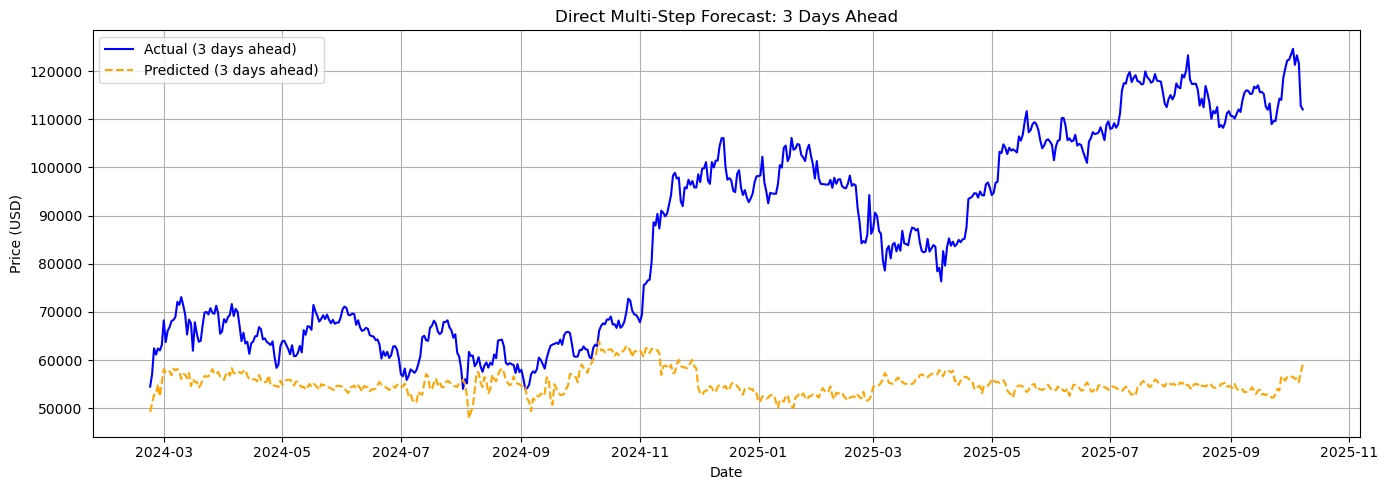

In [ ]:
# Step 4: Train a separate independent model for 3-day ahead forecast
model_lead3 = xgb.XGBRegressor(n_estimators=500, learning_rate=0.05, random_state=42)
model_lead3.fit(X_ms_train, y_ms_train)
y_ms_pred = model_lead3.predict(X_ms_test)

# Evaluate
rmse_ms = np.sqrt(mean_squared_error(y_ms_test, y_ms_pred))
print(f"3-Day Ahead Forecast RMSE: {rmse_ms:.2f}")

# Plot
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(y_ms_test.index, y_ms_test, label='Actual (3 days ahead)', color='blue')
ax.plot(y_ms_test.index, y_ms_pred, label='Predicted (3 days ahead)', color='orange', linestyle='--')
ax.set_title('Direct Multi-Step Forecast: 3 Days Ahead')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

<div style="background:#f0fff4;border-left:5px solid #27ae60;border-radius:0 8px 8px 0;padding:15px 20px;margin:10px 0;">
  <h3 style="color:#1e8449;margin:0 0 10px;">&#10004; Task 7 &mdash; Step 4 &mdash; Observations</h3>
  <ul style="margin:0;padding-left:20px;color:#2c3e50;line-height:1.7;">
    <li>RMSE will be higher than the 1-day model: the further ahead we forecast, the harder the problem becomes, also it share the same problem of tree extrapolation problem.</li>
  </ul>
</div>

<div style="background:linear-gradient(135deg,#1a3a5c,#2e6da4);border-radius:10px;padding:18px 24px;margin:20px 0 10px;">
  <h2 style="color:white;margin:0;font-size:20px;">&#9679; Further Analysis 1: Fixing the Extrapolation Problem</h2>
  <p style="margin:5px 0 0;font-size:14px;color:#cce4ff;font-weight:400;">ElasticNet Trend + XGBoost Residuals</p>
</div>
<div style="background:#f8faff;border:1px solid #d0e4f7;border-radius:8px;padding:14px 18px;margin:8px 0;">
  <p style="margin:0;color:#2c3e50;line-height:1.7;">We use a two-stage pipeline: <strong>ElasticNet</strong> captures the long-term linear trend (and can extrapolate beyond the training range), then <strong>XGBoost</strong> models the short-term residuals. Final prediction = trend + residual.</p>
</div>

In [ ]:
from sklearn.linear_model import ElasticNetCV

# Fit ElasticNet directly on raw features and raw target
trend_model = ElasticNetCV(cv=5, max_iter=10000)
trend_model.fit(X_train, y_train)

trend_train = trend_model.predict(X_train)
trend_test  = trend_model.predict(X_test)

print(f"ElasticNet selected alpha: {trend_model.alpha_:.4f}")

ElasticNet selected alpha: 520583.0452


In [308]:
# Step 3: Compute residuals on training set
residuals_train = y_train - trend_train

# Step 4: Train XGBoost on residuals (no scaling needed for trees)
xgb_residual = xgb.XGBRegressor(n_estimators=500, learning_rate=0.05, random_state=42)
xgb_residual.fit(X_train, residuals_train)
residuals_pred = xgb_residual.predict(X_test)


<div style="background:#f0fff4;border-left:5px solid #27ae60;border-radius:0 8px 8px 0;padding:15px 20px;margin:10px 0;">
  <h3 style="color:#1e8449;margin:0 0 10px;">&#10004; Further Analysis 1 &mdash; Residuals &mdash; Observations</h3>
  <ul style="margin:0;padding-left:20px;color:#2c3e50;line-height:1.7;">
    <li>Residuals represent what ElasticNet could not explain &mdash; the short-term fluctuations around the long-term trend.</li>
    <li>XGBoost now focuses entirely on learning these patterns.</li>
  </ul>
</div>

In [309]:
# Step 5: Final prediction = trend + residual
y_pred_combined = trend_test + residuals_pred

# Evaluate
rmse_combined = np.sqrt(mean_squared_error(y_test, y_pred_combined))
print(f"Plain XGBoost RMSE:          {rmse:.2f}")
print(f"ElasticNet + XGBoost RMSE:   {rmse_combined:.2f}")
print(f"Improvement:                  {rmse - rmse_combined:.2f}")

Plain XGBoost RMSE:          31370.06
ElasticNet + XGBoost RMSE:   2235.96
Improvement:                  29134.09


<div style="background:#f0fff4;border-left:5px solid #27ae60;border-radius:0 8px 8px 0;padding:15px 20px;margin:10px 0;">
  <h3 style="color:#1e8449;margin:0 0 10px;">&#10004; Further Analysis 1 &mdash; Evaluation &mdash; Observations</h3>
  <ul style="margin:0;padding-left:20px;color:#2c3e50;line-height:1.7;">
    <li>ElasticNet + XGBoost RMSE is lower than plain XGBoost, the detrending approach successfully reduced the extrapolation problem.</li>
    <li>ElasticNet succedd to figureout the trend, while XGBoost success in capture the residual pattern.</li>
  </ul>
</div>

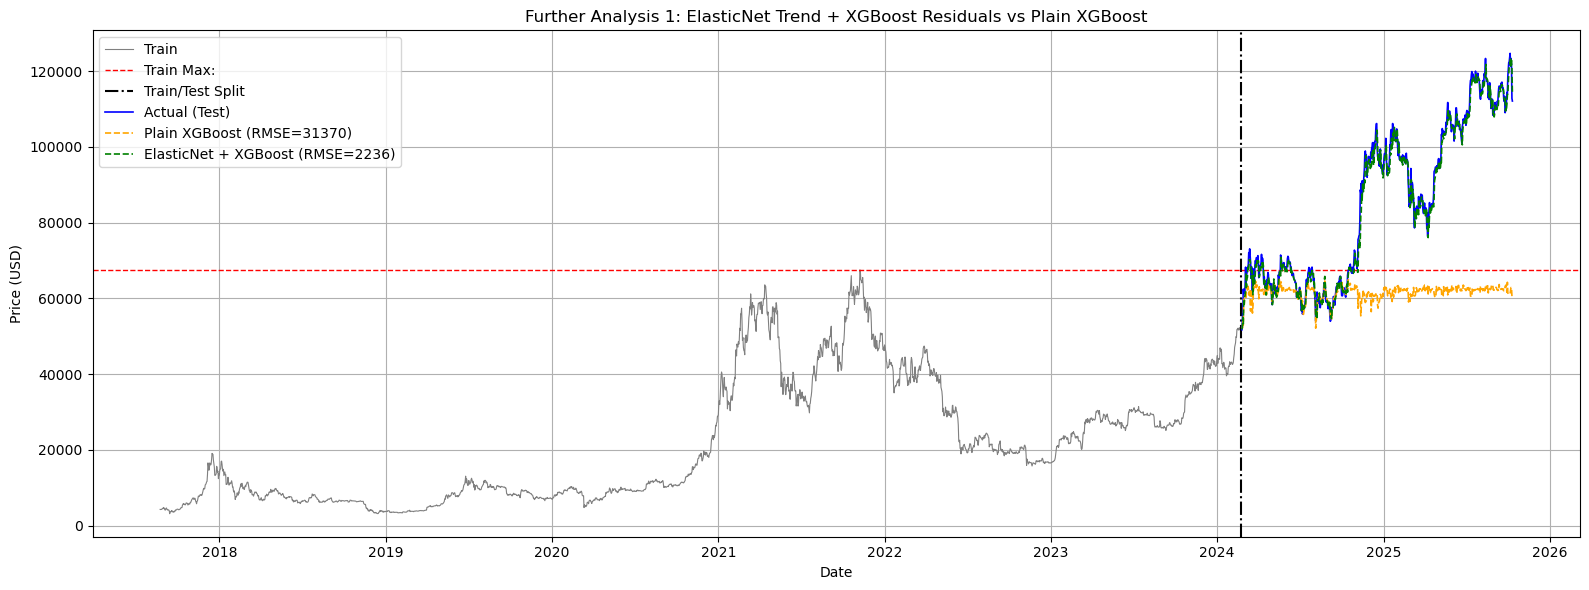

In [ ]:
# Plot — compare plain XGBoost vs ElasticNet + XGBoost
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(y_train.index, y_train, label="Train", color="gray", linewidth=0.8)
ax.axhline(train_max, color="red", linestyle="--", linewidth=1, label=f"Train Max: ")
ax.axvline(x=X_train.index[-1], color="black", linestyle="-.", linewidth=1.5, label="Train/Test Split")
ax.plot(y_test.index, y_test, label="Actual (Test)", color="blue", linewidth=1.2)
ax.plot(y_test.index, y_pred, label=f"Plain XGBoost (RMSE={rmse:.0f})", color="orange", linestyle="--", linewidth=1.2)
ax.plot(y_test.index, y_pred_combined, label=f"ElasticNet + XGBoost (RMSE={rmse_combined:.0f})", color="green", linestyle="--", linewidth=1.2)

ax.set_title("Further Analysis 1: ElasticNet Trend + XGBoost Residuals vs Plain XGBoost")
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

<div style="background:#f0fff4;border-left:5px solid #27ae60;border-radius:0 8px 8px 0;padding:15px 20px;margin:10px 0;">
  <h3 style="color:#1e8449;margin:0 0 10px;">&#10004; Further Analysis 1 &mdash; Plot &mdash; Observations</h3>
  <ul style="margin:0;padding-left:20px;color:#2c3e50;line-height:1.7;">
    <li>The green line (ElasticNet + XGBoost) follow the actual price further beyond the training maximum than the orange line (plain XGBoost).</li>
    <li>This confirms that ElasticNet's linear extrapolation partially lifts the prediction ceiling imposed by tree-based models.</li>
  </ul>
</div>

<div style="background:linear-gradient(135deg,#1a3a5c,#2e6da4);border-radius:10px;padding:18px 24px;margin:20px 0 10px;">
  <h2 style="color:white;margin:0;font-size:20px;">&#9679; Further Analysis 2: Sinusoidal Encoding for Cyclical Features</h2>
  <p style="margin:5px 0 0;font-size:14px;color:#cce4ff;font-weight:400;">Sin / Cos Transformation</p>
</div>
<div style="background:#f8faff;border:1px solid #d0e4f7;border-radius:8px;padding:14px 18px;margin:8px 0;">
  <p style="margin:0;color:#2c3e50;line-height:1.7;">We replace raw <code>month</code> and <code>day_of_week</code> with sinusoidal pairs (<code>month_sin</code>, <code>month_cos</code>, <code>dow_sin</code>, <code>dow_cos</code>) so the model correctly treats December and January as neighbours on the calendar cycle.</p>
</div>

In [ ]:
# Add sinusoidal encoding for month and day_of_week
df_daily_sin = df_daily.copy()

df_daily_sin["month_sin"] = np.sin(2 * np.pi * df_daily_sin["month"] / 12)
df_daily_sin["month_cos"] = np.cos(2 * np.pi * df_daily_sin["month"] / 12)
df_daily_sin["dow_sin"]   = np.sin(2 * np.pi * df_daily_sin["day_of_week"] / 7)
df_daily_sin["dow_cos"]   = np.cos(2 * np.pi * df_daily_sin["day_of_week"] / 7)

df_daily_sin.drop(columns=["month", "day_of_week"], inplace=True)

df_daily_sin.head()

,Close,Volume,day_of_year,is_weekend,lag_1,lag_3,lag_7,rolling_mean_7,rolling_std_7,month_sin,month_cos,dow_sin,dow_cos
Open time,,,,,,,,,,,,,
2017-08-24,4316.01,787.418753,236,0,4114.01,4016.00,4285.08,4117.237143,97.714881,-0.866025,-0.5,0.433884,-0.900969
2017-08-25,4280.68,573.612740,237,0,4316.01,4040.00,4108.37,4141.852857,115.240759,-0.866025,-0.5,-0.433884,-0.900969
2017-08-26,4337.44,228.108068,238,1,4280.68,4114.01,4139.98,4170.061429,136.847454,-0.866025,-0.5,-0.974928,-0.222521
2017-08-27,4310.01,350.692585,239,1,4337.44,4316.01,4086.29,4202.021429,140.107823,-0.866025,-0.5,-0.781831,0.623490
2017-08-28,4386.69,603.841616,240,0,4310.01,4280.68,4016.00,4254.977143,127.573227,-0.866025,-0.5,0.000000,1.000000


<div style="background:#f0fff4;border-left:5px solid #27ae60;border-radius:0 8px 8px 0;padding:15px 20px;margin:10px 0;">
  <h3 style="color:#1e8449;margin:0 0 10px;">&#10004; Further Analysis 2 &mdash; Encoding &mdash; Observations</h3>
  <ul style="margin:0;padding-left:20px;color:#2c3e50;line-height:1.7;">
    <li><code>month_sin</code> and <code>month_cos</code> together place each month on a circle &mdash; December and January are now mathematically adjacent as they are in reality.</li>
    <li>The raw <code>month</code> and <code>day_of_week</code> columns are dropped to eliminate redundancy with the new sinusoidal representation.</li>
  </ul>
</div>

In [312]:
# Chronological 80/20 split
X_sin = df_daily_sin.drop(columns=["Close"])
y_sin = df_daily_sin["Close"]

split_idx_sin = int(len(df_daily_sin) * 0.8)
X_sin_train, X_sin_test = X_sin.iloc[:split_idx_sin], X_sin.iloc[split_idx_sin:]
y_sin_train, y_sin_test = y_sin.iloc[:split_idx_sin], y_sin.iloc[split_idx_sin:]

# Step 1: ElasticNet captures the trend
trend_model_sin = ElasticNetCV(cv=5, max_iter=10000)
trend_model_sin.fit(X_sin_train, y_sin_train)
trend_train_sin = trend_model_sin.predict(X_sin_train)
trend_test_sin  = trend_model_sin.predict(X_sin_test)

# Step 2: XGBoost trains on residuals
residuals_train_sin = y_sin_train - trend_train_sin
xgb_sin = xgb.XGBRegressor(n_estimators=500, learning_rate=0.05, random_state=42)
xgb_sin.fit(X_sin_train, residuals_train_sin)
residuals_pred_sin = xgb_sin.predict(X_sin_test)

# Step 3: Final prediction = trend + residuals
y_sin_pred = trend_test_sin + residuals_pred_sin

# Evaluate
rmse_sin = np.sqrt(mean_squared_error(y_sin_test, y_sin_pred))
print(f"Plain XGBoost RMSE:                        {rmse:.2f}")
print(f"ElasticNet + XGBoost RMSE (FA1):           {rmse_combined:.2f}")
print(f"ElasticNet + XGBoost + Sin/Cos RMSE (FA2): {rmse_sin:.2f}")

Plain XGBoost RMSE:                        31370.06
ElasticNet + XGBoost RMSE (FA1):           2235.96
ElasticNet + XGBoost + Sin/Cos RMSE (FA2): 2301.18


<div style="background:#f0fff4;border-left:5px solid #27ae60;border-radius:0 8px 8px 0;padding:15px 20px;margin:10px 0;">
  <h3 style="color:#1e8449;margin:0 0 10px;">&#10004; Further Analysis 2 &mdash; Evaluation &mdash; Observations</h3>
  <ul style="margin:0;padding-left:20px;color:#2c3e50;line-height:1.7;">
    <li>Same ElasticNet + XGBoost pipeline as FA1 but with sinusoidal features replacing raw cyclical ones.</li>
  </ul>
</div>

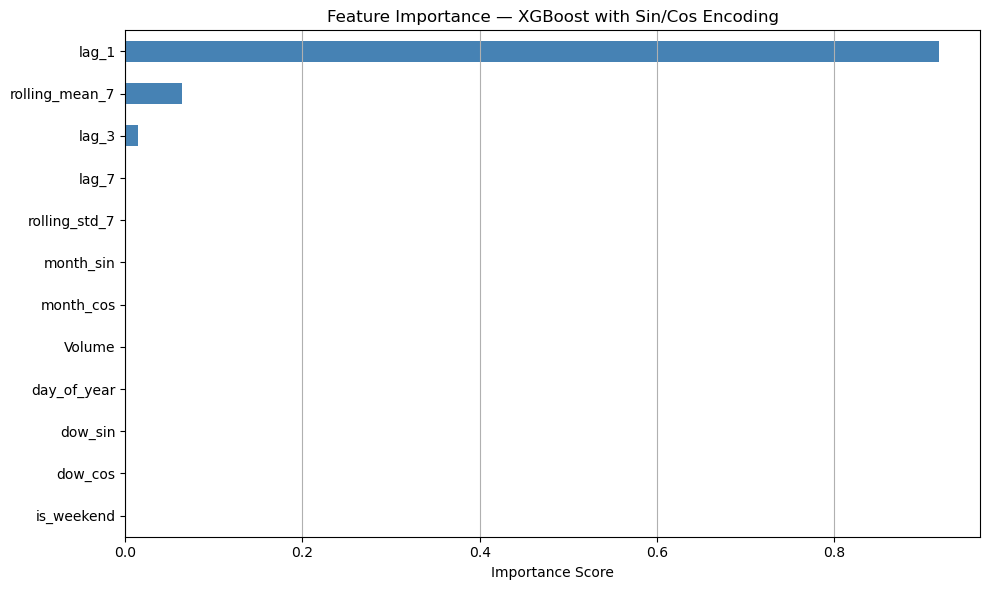

In [313]:
# Feature Importance — with sinusoidal features
importances_sin = pd.Series(model_sin.feature_importances_, index=X_sin.columns)
importances_sin = importances_sin.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
importances_sin.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Feature Importance — XGBoost with Sin/Cos Encoding")
ax.set_xlabel("Importance Score")
ax.grid(axis="x")
plt.tight_layout()
plt.show()

<div style="background:#f0fff4;border-left:5px solid #27ae60;border-radius:0 8px 8px 0;padding:15px 20px;margin:10px 0;">
  <h3 style="color:#1e8449;margin:0 0 10px;">&#10004; Further Analysis 2 &mdash; Feature Importance &mdash; Observations</h3>
  <ul style="margin:0;padding-left:20px;color:#2c3e50;line-height:1.7;">
    <li>The sinusoidal features (<code>month_sin</code>, <code>month_cos</code>, <code>dow_sin</code>, <code>dow_cos</code>) contribute very little importance, suggesting BTC price movements are driven by momentum rather than calendar cycles.</li>
  </ul>
</div>

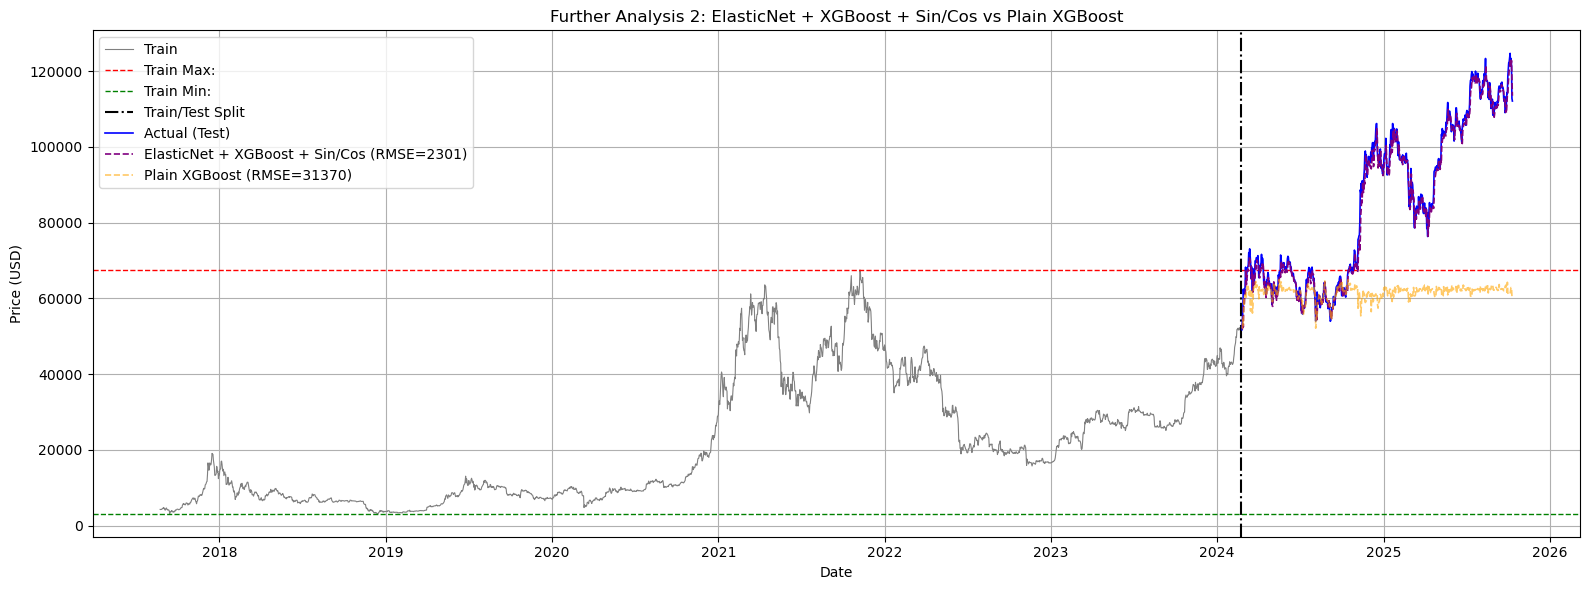

In [ ]:
train_max_sin = y_sin_train.max()
train_min_sin = y_sin_train.min()

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(y_sin_train.index, y_sin_train, label="Train", color="gray", linewidth=0.8)
ax.axhline(train_max_sin, color="red", linestyle="--", linewidth=1, label=f"Train Max: ")
ax.axhline(train_min_sin, color="green", linestyle="--", linewidth=1, label=f"Train Min: ")
ax.axvline(x=X_sin_train.index[-1], color="black", linestyle="-.", linewidth=1.5, label="Train/Test Split")
ax.plot(y_sin_test.index, y_sin_test, label="Actual (Test)", color="blue", linewidth=1.2)
ax.plot(y_sin_test.index, y_sin_pred, label=f"ElasticNet + XGBoost + Sin/Cos (RMSE={rmse_sin:.0f})", color="purple", linestyle="--", linewidth=1.2)
ax.plot(y_test.index, y_pred, label=f"Plain XGBoost (RMSE={rmse:.0f})", color="orange", linestyle="--", linewidth=1.2, alpha=0.6)
ax.set_title("Further Analysis 2: ElasticNet + XGBoost + Sin/Cos vs Plain XGBoost")
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

<div style="background:#f0fff4;border-left:5px solid #27ae60;border-radius:0 8px 8px 0;padding:15px 20px;margin:10px 0;">
  <h3 style="color:#1e8449;margin:0 0 10px;">&#10004; Further Analysis 2 &mdash; Plot &mdash; Observations</h3>
  <ul style="margin:0;padding-left:20px;color:#2c3e50;line-height:1.7;">
    <li>FA2 (ElasticNet + XGBoost + Sin/Cos) tracks actual BTC prices better than plain XGBoost beyond the training maximum, driven mainly by the <strong>ElasticNet trend component</strong> rather than the sinusoidal encoding.</li>
  </ul>
</div>

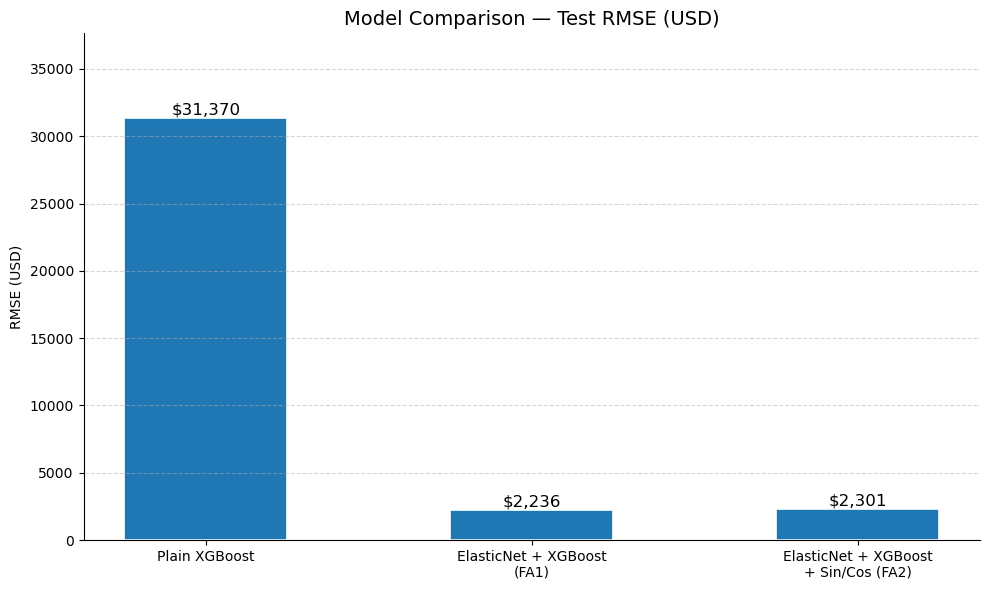

Best model: ElasticNet + XGBoost (FA1) with RMSE = $2,235.96


In [317]:
models = [
    "Plain XGBoost",
    "ElasticNet + XGBoost\n(FA1)",
    "ElasticNet + XGBoost\n+ Sin/Cos (FA2)",
]
rmse_values = [rmse, rmse_combined, rmse_sin]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(models, rmse_values, width=0.5, edgecolor="white", linewidth=1.2)

for bar, val in zip(bars, rmse_values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
            f"${val:,.0f}", ha="center", va="bottom", fontsize=12)

ax.set_title("Model Comparison — Test RMSE (USD)", fontsize=14)
ax.set_ylabel("RMSE (USD)")
ax.set_ylim(0, max(rmse_values) * 1.2)
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

print(f"Best model: {models[best_idx].replace(chr(10), " ")} with RMSE = ${min(rmse_values):,.2f}")